In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

In [39]:
df = pd.read_csv('set2_health.csv')
df.isnull().sum()



Age               187
BMI               194
Blood_Pressure    216
Glucose_Level     207
Insulin           182
Risk              211
dtype: int64

In [48]:
cols = ['BMI', 'Blood_Pressure', 'Glucose_Level', 'Insulin']
df[cols] = df[cols].replace(0, np.nan)
df[cols] = df[cols].fillna(df[cols].median())

In [50]:
X = df.drop("Risk", axis=1)
y = df["Risk"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [51]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)


In [52]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [55]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n--- Model Evaluation ---")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")



--- Model Evaluation ---
Accuracy  : 0.9382
Precision : 0.9146
Recall    : 0.9421
F1 Score  : 0.9282


In [59]:

y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

print("auc:",auc)

auc: 0.9387518896447469


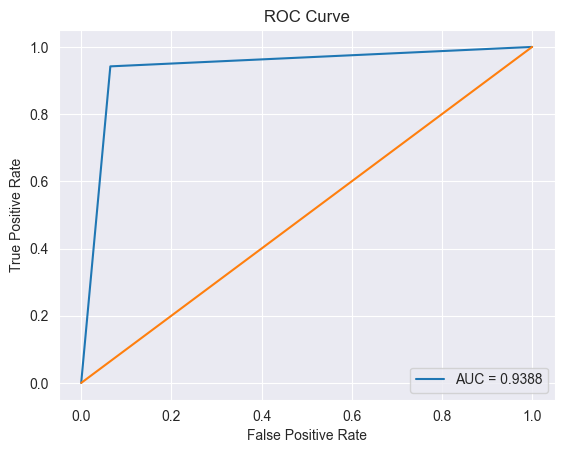

In [57]:

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1])  # diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()